## **Import Libraries**

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn import svm
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

## **Read Data**

In [35]:
df = pd.read_csv("home-prices.csv")
df.head()

,price,age,landValue,livingArea,bedrooms,bathrooms,rooms,heating,fuel,waterfront,newConstruction,centralAir
0,132500,42,50000,906,2,1.0,5,electric,electric,No,No,No
1,181115,0,22300,1953,3,2.5,6,hot water/steam,gas,No,No,No
2,109000,133,7300,1944,4,1.0,8,hot water/steam,gas,No,No,No
3,155000,13,18700,1944,3,1.5,5,hot air,gas,No,No,No
4,86060,0,15000,840,2,1.0,3,hot air,gas,No,Yes,Yes


In [37]:
df.describe().round()

,price,age,landValue,livingArea,bedrooms,bathrooms,rooms
count,1728.0,1728.0,1728.0,1728.0,1728.0,1728.0,1728.0
mean,211967.0,28.0,34557.0,1755.0,3.0,2.0,7.0
std,98441.0,29.0,35021.0,620.0,1.0,1.0,2.0
min,5000.0,0.0,200.0,616.0,1.0,0.0,2.0
25%,145000.0,13.0,15100.0,1300.0,3.0,2.0,5.0
50%,189900.0,19.0,25000.0,1634.0,3.0,2.0,7.0
75%,259000.0,34.0,40200.0,2138.0,4.0,2.0,8.0
max,775000.0,225.0,412600.0,5228.0,7.0,4.0,12.0


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   price            1728 non-null   int64  
 1   age              1728 non-null   int64  
 2   landValue        1728 non-null   int64  
 3   livingArea       1728 non-null   int64  
 4   bedrooms         1728 non-null   int64  
 5   bathrooms        1728 non-null   float64
 6   rooms            1728 non-null   int64  
 7   heating          1728 non-null   object 
 8   fuel             1728 non-null   object 
 9   waterfront       1728 non-null   object 
 10  newConstruction  1728 non-null   object 
 11  centralAir       1728 non-null   object 
dtypes: float64(1), int64(6), object(5)
memory usage: 162.1+ KB


In [41]:
num_col = ["price","age","livingArea","bedrooms","rooms"]
cat_col = ["heating","fuel","waterfront","newConstruction","centralAir"]

## **Encoding**

In [43]:
ll = LabelEncoder()

In [45]:
for col in cat_col:
    df[col] = ll.fit_transform(df[col])    

In [47]:
df.head()

,price,age,landValue,livingArea,bedrooms,bathrooms,rooms,heating,fuel,waterfront,newConstruction,centralAir
0,132500,42,50000,906,2,1.0,5,0,0,0,0,0
1,181115,0,22300,1953,3,2.5,6,2,1,0,0,0
2,109000,133,7300,1944,4,1.0,8,2,1,0,0,0
3,155000,13,18700,1944,3,1.5,5,1,1,0,0,0
4,86060,0,15000,840,2,1.0,3,1,1,0,1,1


## **Correlation Between Numerical Features**

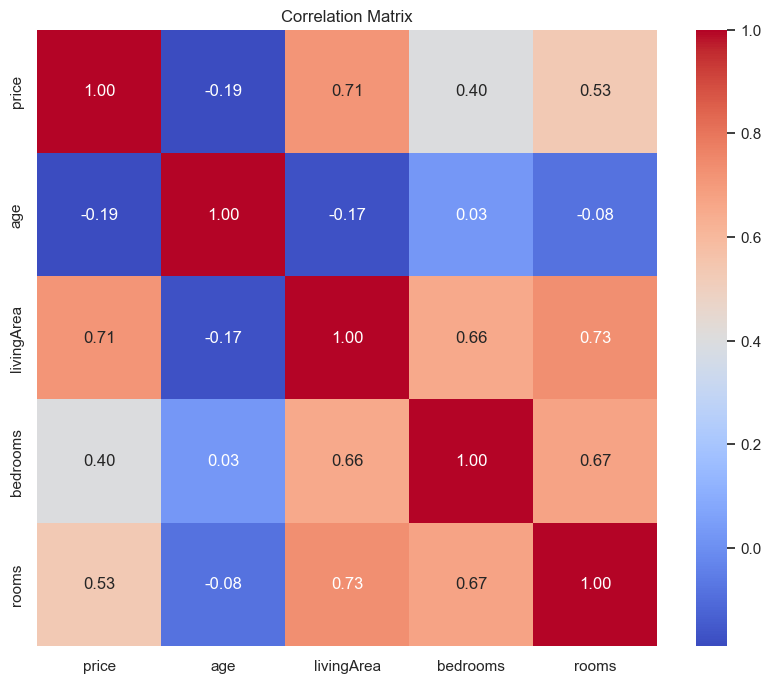

In [49]:
correlation_matrix = df[num_col].corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## **Outliers Detection**

<Figure size 1000x800 with 0 Axes>

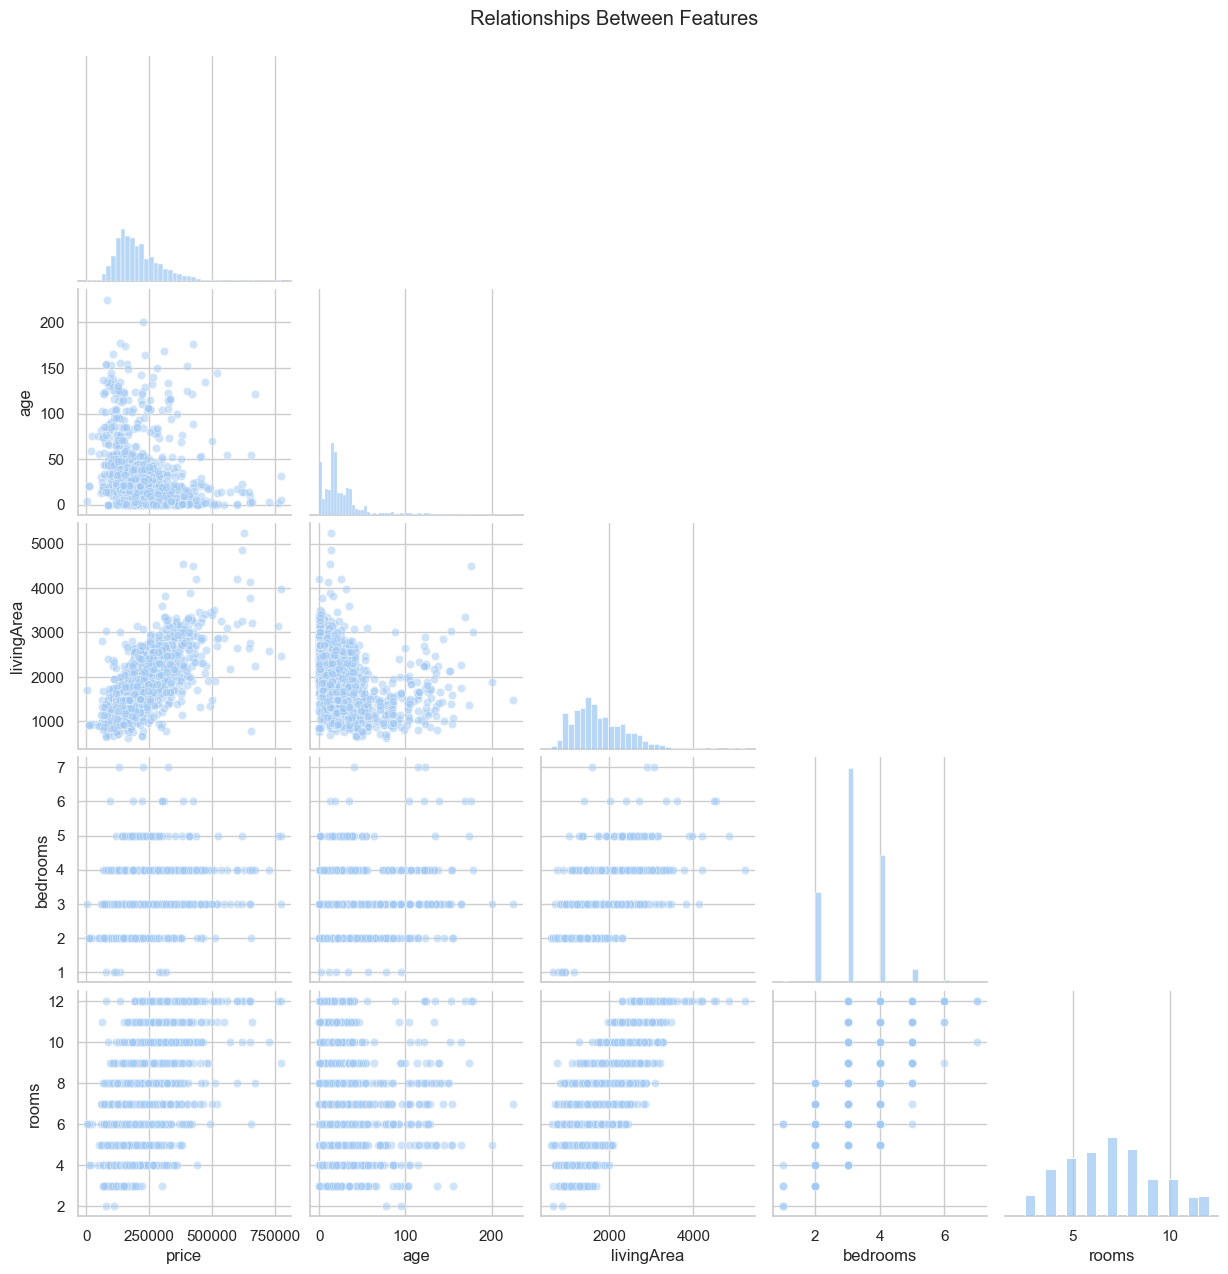

In [51]:
sns.set_theme(style="whitegrid", palette="pastel")
plt.figure(figsize=(10,8))
sns.pairplot(df[num_col], corner=True, plot_kws={"alpha": 0.5})
plt.suptitle("Relationships Between Features", y=1.02)
plt.show()

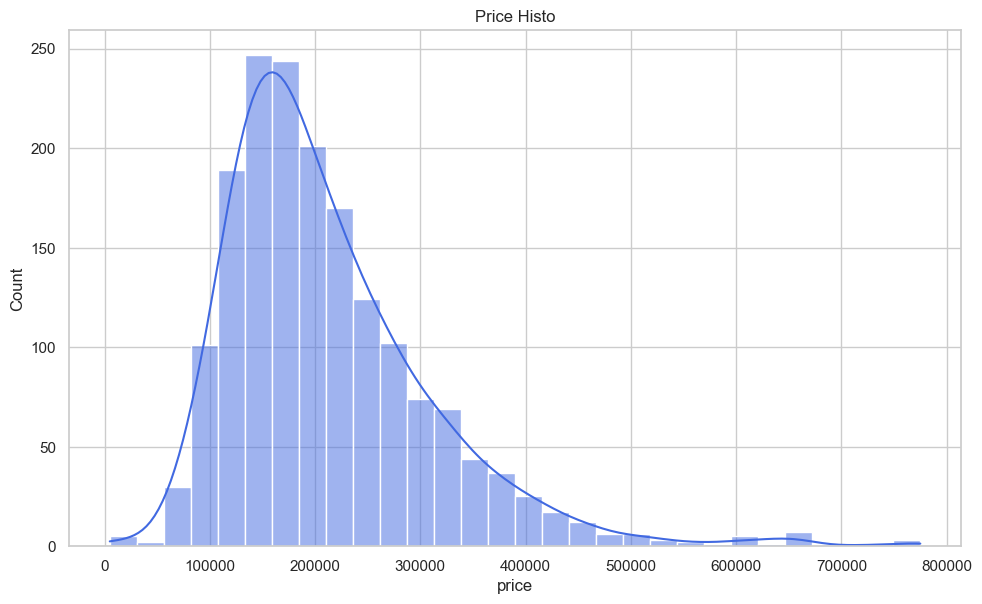

In [53]:
sns.set_theme(style="whitegrid", palette="pastel")
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, color='royalblue', bins=30)
plt.tight_layout()
plt.title("Price Histo")
plt.savefig('price_distribution.png', dpi=300)
plt.show()

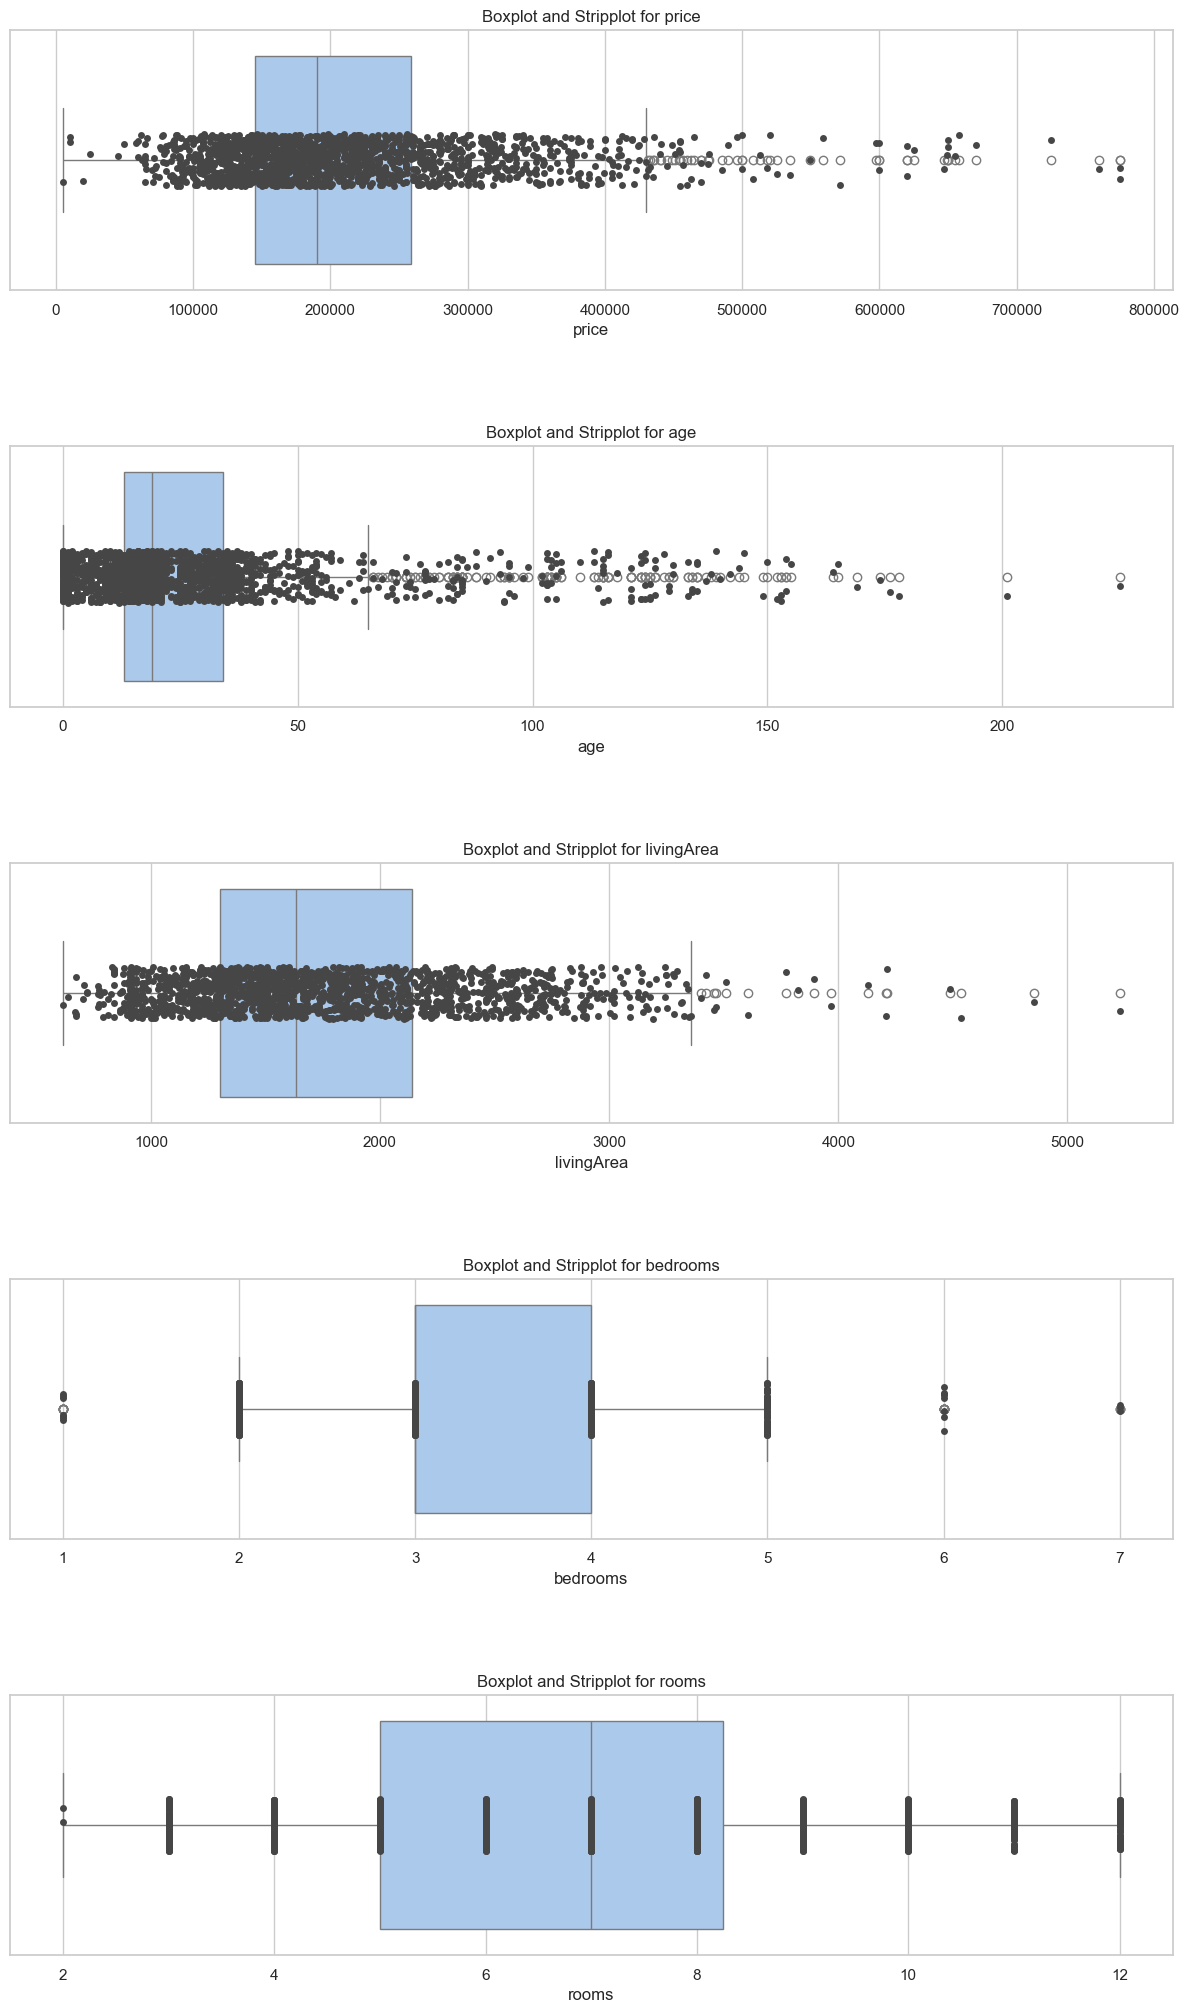

In [55]:
fig,axes = plt.subplots(len(num_col),1,figsize = (15,5*len(num_col)))
fig.subplots_adjust(hspace=0.6)
axes.flatten()
for i, col in enumerate(num_col):
    sns.boxplot(x=col, data=df, ax=axes[i])
    sns.stripplot(x=col, data=df, color="#474646", ax=axes[i])
    axes[i].set_title(f"Boxplot and Stripplot for {col}")
    axes[i].set_xlabel(col)

## **Handling Outliers**

In [57]:
for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [59]:
df.shape

(1518, 12)

In [61]:
df.describe()

,price,age,landValue,livingArea,bedrooms,bathrooms,rooms,heating,fuel,waterfront,newConstruction,centralAir
count,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000
mean,203448.683136,20.648880,31978.932806,1731.111989,3.134387,1.916337,6.954545,0.959816,0.899209,0.003294,0.051383,0.384717
std,76529.148200,13.589661,29133.906037,558.396031,0.767065,0.619064,2.223780,0.591384,0.541963,0.057316,0.220851,0.486689
min,5000.000000,0.000000,200.000000,640.000000,2.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,147837.250000,12.000000,15100.000000,1310.250000,3.000000,1.500000,5.000000,1.000000,1.000000,0.000000,0.000000,0.000000
50%,189000.000000,18.000000,25000.000000,1633.000000,3.000000,2.000000,7.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,249883.750000,30.000000,37450.000000,2110.750000,4.000000,2.500000,8.000000,1.000000,1.000000,0.000000,0.000000,1.000000
max,430000.000000,65.000000,250000.000000,3328.000000,5.000000,4.000000,12.000000,2.000000,2.000000,1.000000,1.000000,1.000000


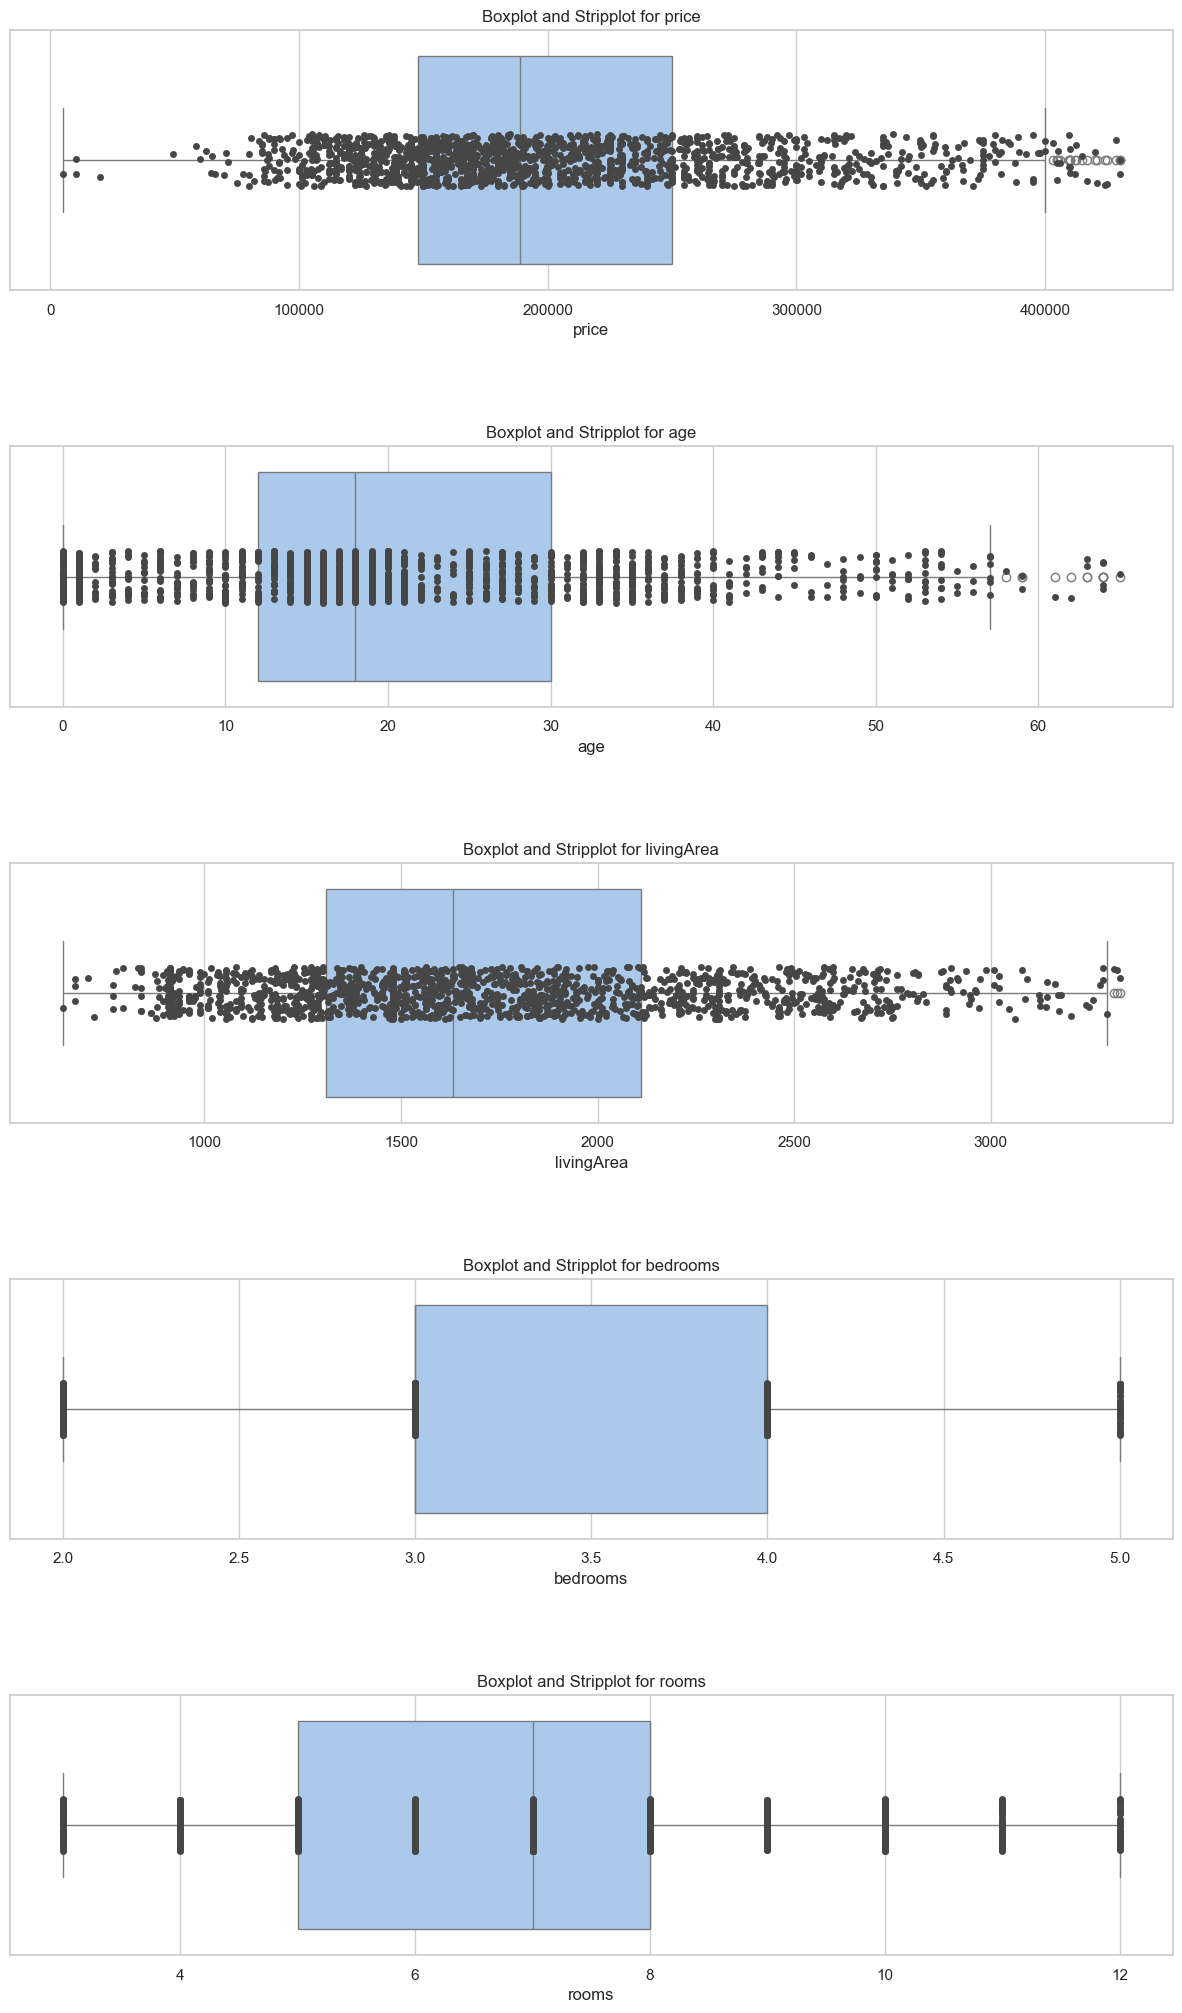

In [63]:
fig,axes = plt.subplots(len(num_col),1,figsize = (15,5*len(num_col)))
fig.subplots_adjust(hspace=0.6)
axes.flatten()
for i, col in enumerate(num_col):
    sns.boxplot(x=col, data=df, ax=axes[i])
    sns.stripplot(x=col, data=df, color="#474646", ax=axes[i])
    axes[i].set_title(f"Boxplot and Stripplot for {col}")
    axes[i].set_xlabel(col)

## **Data Splitting**

In [65]:
X = df.drop("price" , axis=1)
y = df["price"]

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **Data Scalling**

In [69]:
scaler = StandardScaler()

In [71]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **Linear Regression**

In [73]:
LR = LinearRegression()

In [75]:
LR.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [77]:
y_pred_LR = LR.predict(X_test_scaled)

In [79]:
mse_LR = mean_squared_error(y_test, y_pred_LR)
rmse_LR = np.sqrt(mse_LR)
r2_LR = r2_score(y_test, y_pred_LR)

print("Linear Regression Metrics")
print("MSE : ", round(mse_LR, 4))
print("RMSE : ", round(rmse_LR, 4))
print("R² Score : ", round(r2_LR, 4))

Linear Regression Metrics
MSE :  2239202727.02
RMSE :  47320.2148
R² Score :  0.5734


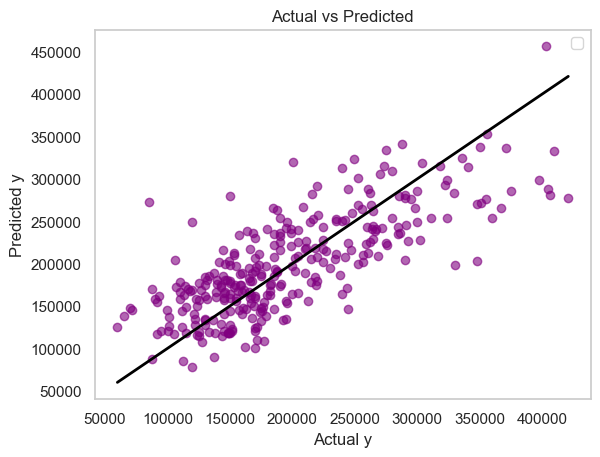

In [166]:
plt.scatter(y_test, y_pred_LR, color="purple", alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="black", linewidth=2)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.title("Actual vs Predicted")
plt.grid()
plt.legend()
plt.show()

## **Decision Tree for Regression**

In [81]:
DT = DecisionTreeRegressor()

In [83]:
DT.fit(X_train_scaled,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [85]:
y_pred_DT = DT.predict(X_test_scaled)

In [87]:
mse_DT = mean_squared_error(y_test, y_pred_DT)
rmse_DT = np.sqrt(mse_DT)
r2_DT = r2_score(y_test, y_pred_DT)

print("Decision Tree Metrics")
print("MSE : ", round(mse_DT, 4))
print("RMSE : ", round(rmse_DT, 4))
print("R² Score : ", round(r2_DT, 4))

Decision Tree Metrics
MSE :  4261234660.8783
RMSE :  65278.1331
R² Score :  0.1881


## **Random Forest for Regression**

In [89]:
RF = RandomForestRegressor()

In [91]:
RF.fit(X_train_scaled,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [93]:
y_pred_RF = RF.predict(X_test_scaled)

In [95]:
mse_RF = mean_squared_error(y_test, y_pred_RF)
rmse_RF = np.sqrt(mse_RF)
r2_RF = r2_score(y_test, y_pred_RF)

print("Random Forest Metrics")
print("MSE : ", round(mse_RF, 4))
print("RMSE : ", round(rmse_RF, 4))
print("R² Score : ", round(r2_RF, 4))

Random Forest Metrics
MSE :  2077367171.523
RMSE :  45578.1436
R² Score :  0.6042


## **Hyper Parameters Tuning with Grid Search** 

In [97]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['auto','sqrt']
}

In [99]:
grid_search = GridSearchCV(estimator=RF,
                           param_grid=param_grid,
                           cv=3,
                           scoring='r2',
                           n_jobs=-1,
                           verbose=1)

grid_search.fit(X_train_scaled,y_train)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [None, 10, ...], 'max_features': ['auto', 'sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [101]:
print("Best Parameters:", grid_search.best_params_)
print("Best Score (CV):", grid_search.best_score_)

Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Score (CV): 0.6819858134593457


In [103]:
best_model = grid_search.best_estimator_
y_pred_RF = best_model.predict(X_test_scaled)
print("Test R2 Score:", r2_score(y_test, y_pred_RF))

Test R2 Score: 0.625421173395939


## **Support Vector for Regression**

In [105]:
svr = svm.SVR(kernel='linear', C=10, gamma='auto')

In [107]:
svr.fit(X_train_scaled,y_train)

,kernel,'linear'
,degree,3
,gamma,'auto'
,coef0,0.0
,tol,0.001
,C,10
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [109]:
y_pred_svr= svr.predict(X_test_scaled)

In [111]:
mse_SVR = mean_squared_error(y_test, y_pred_svr)
rmse_SVR = np.sqrt(mse_SVR)
r2_SVR = r2_score(y_test, y_pred_svr)

print("SVR Metrics")
print("MSE : ", round(mse_SVR, 4))
print("RMSE : ", round(rmse_SVR, 4))
print("R² Score : ", round(r2_SVR, 4))

SVR Metrics
MSE :  3480552591.8047
RMSE :  58996.2083
R² Score :  0.3368


## **XGBoosting for Regression**

In [113]:
XGB = XGBRegressor()

In [115]:
XGB.fit(X_train_scaled,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [117]:
y_pred_XGB= XGB.predict(X_test_scaled)

In [119]:
mse_XGB = mean_squared_error(y_test, y_pred_XGB)
rmse_XGB = np.sqrt(mse_XGB)
r2_XGB = r2_score(y_test, y_pred_XGB)

print("SVR Metrics")
print("MSE : ", round(mse_XGB, 4))
print("RMSE : ", round(rmse_XGB, 4))
print("R² Score : ", round(r2_XGB, 4))

SVR Metrics
MSE :  2300003584.0
RMSE :  47958.3526
R² Score :  0.5618


## **Hyper Parameters Tuning with Grid Search** 

In [121]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.3],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0]
}

In [123]:
grid_search = GridSearchCV(
    estimator=XGB,
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    verbose=1,
    n_jobs=-1
)

In [125]:
grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.7, 1.0], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [127]:
print("Best parameters:", grid_search.best_params_)
print("Best R2 Score on validation set:", grid_search.best_score_)

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}
Best R2 Score on validation set: 0.6903027057647705


In [129]:
best_model = grid_search.best_estimator_
y_pred_XGB = best_model.predict(X_test_scaled)
print("Test R2 Score:", r2_score(y_test, y_pred_XGB))

Test R2 Score: 0.6171368360519409


## **Comparison Of Model Accuracies**

In [131]:
from matplotlib.ticker import PercentFormatter

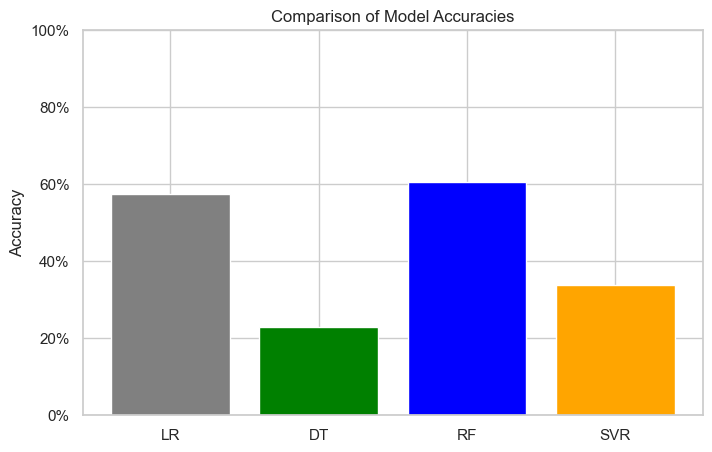

In [133]:
models = ["LR","DT","RF","SVR"]
accuracies = [r2_LR , r2_DT , r2_RF , r2_SVR]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=["Gray", "green", "blue", "orange"])
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.ylabel("Accuracy")
plt.title("Comparison of Model Accuracies")
plt.show()

---